#Student Dropout Data Engineering Pipeline
**Student:** Muneera Almojel

**Major:** Information Systems

**Program:** SDAIA Academy - Data Engineering for AI Systems (DAICO)

**Trainer** Mohammed Albeladi

## 📖 Project Overview

This project presents an end-to-end data engineering pipeline for predicting student academic status using a real-world dataset. The pipeline includes data ingestion, data validation, Bronze, Silver, Gold layers, and a machine learning model.

## 📚 Import Libraries

The required Python libraries are imported to support data processing, visualization, and machine learning.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Data Ingestion
In this stage, the raw dataset is loaded into the pipeline for processing.

In [29]:
file_path = "/content/Data dropout.csv"

raw_df = pd.read_csv(file_path, sep=";")

print("Dataset loaded successfully.")
print("Number of rows:", raw_df.shape[0])
print("Number of columns:", raw_df.shape[1])

raw_df.head()

Dataset loaded successfully.
Number of rows: 4424
Number of columns: 37


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 🔍 Dataset Overview

This section provides an overview of the dataset including its dimensions, column names, and basic statistics.

In [30]:
print("Column names:")
print(raw_df.columns.tolist())

print("\nTarget values:")
print(raw_df["Target"].value_counts())

Column names:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target

#Bronze Layer 🥉
The Bronze layer stores the raw dataset without any modifications.

In [31]:

bronze_df = raw_df.copy()

bronze_df.to_csv("/content/bronze_student_dropout.csv", index=False)

print("Bronze Layer Created Successfully")
bronze_df.head()

Bronze Layer Created Successfully


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


#Data Validation✅
This stage checks the dataset structure, missing values, duplicates, and data quality before transformation.

In [32]:

print("Shape:")
print(raw_df.shape)

print("\nColumns:")
print(raw_df.columns)

print("\nData Types:")
print(raw_df.dtypes)

print("\nMissing Values:")
print(raw_df.isnull().sum())

Shape:
(4424, 37)

Columns:
Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',


In [33]:
raw_df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [34]:
raw_df["Target"].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


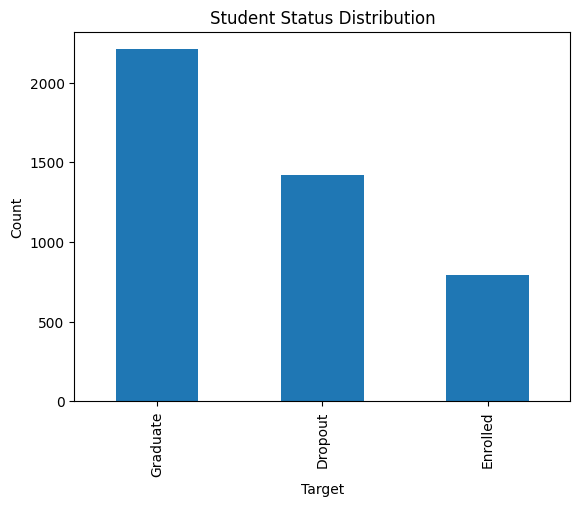

In [35]:
import matplotlib.pyplot as plt

raw_df["Target"].value_counts().plot(kind="bar")

plt.title("Student Status Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

## Silver Layer🥈

The Silver layer cleans and prepares the dataset for analysis.

In [36]:
silver_df = bronze_df.copy()

# Clean column names
silver_df.columns = (
    silver_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("/", "_")
    .str.replace(r"[^\w]", "", regex=True)
)

print("Column names cleaned successfully.")
print(silver_df.columns.tolist())

Column names cleaned successfully.
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Target']


In [37]:
# Remove duplicated rows
rows_before = len(silver_df)

silver_df = silver_df.drop_duplicates()

rows_after = len(silver_df)

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Duplicates removed:", rows_before - rows_after)

print("\nTotal missing values:", silver_df.isnull().sum().sum())

Rows before removing duplicates: 4424
Rows after removing duplicates: 4424
Duplicates removed: 0

Total missing values: 0


In [38]:

# Basic validation checks

validation_results = {
    "Dataset is not empty": len(silver_df) > 0,
    "Target column exists": "Target" in silver_df.columns,
    "No missing values": silver_df.isnull().sum().sum() == 0,
    "No duplicated rows": silver_df.duplicated().sum() == 0,
    "Target has valid classes": set(silver_df["Target"].unique()) == {
        "Dropout",
        "Graduate",
        "Enrolled"
    }
}

for check, result in validation_results.items():
    print(f"{check}: {'PASSED' if result else 'FAILED'}")

Dataset is not empty: PASSED
Target column exists: PASSED
No missing values: PASSED
No duplicated rows: PASSED
Target has valid classes: PASSED


In [39]:
silver_df.to_csv(
    "/content/silver_student_dropout.csv",
    index=False
)

print("Silver Layer Created Successfully.")
print("Silver dataset shape:", silver_df.shape)

silver_df.head()

Silver Layer Created Successfully.
Silver dataset shape: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


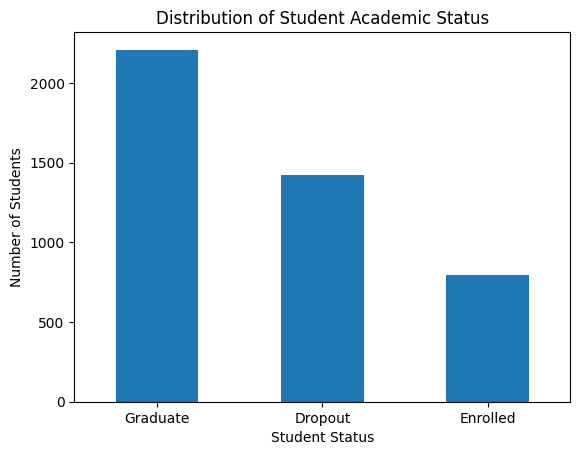

In [40]:
target_counts = silver_df["Target"].value_counts()

target_counts.plot(kind="bar")

plt.title("Distribution of Student Academic Status")
plt.xlabel("Student Status")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

In [41]:
target_percentage = (
    silver_df["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Target Distribution Percentage:")
print(target_percentage)

Target Distribution Percentage:
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


##  Gold Layer🥇

The Gold layer contains aggregated and analysis-ready data generated from the cleaned Silver dataset.

In [42]:
gold_df = (
    silver_df["Target"]
    .value_counts()
    .reset_index()
)

gold_df.columns = ["Student_Status", "Student_Count"]

gold_df["Percentage"] = (
    gold_df["Student_Count"] / gold_df["Student_Count"].sum() * 100
).round(2)

gold_df

,Student_Status,Student_Count,Percentage
0,Graduate,2209,49.93
1,Dropout,1421,32.12
2,Enrolled,794,17.95


In [43]:
gold_df.to_csv(
    "/content/gold_student_dropout_summary.csv",
    index=False
)

print("Gold Layer Created Successfully.")

Gold Layer Created Successfully.


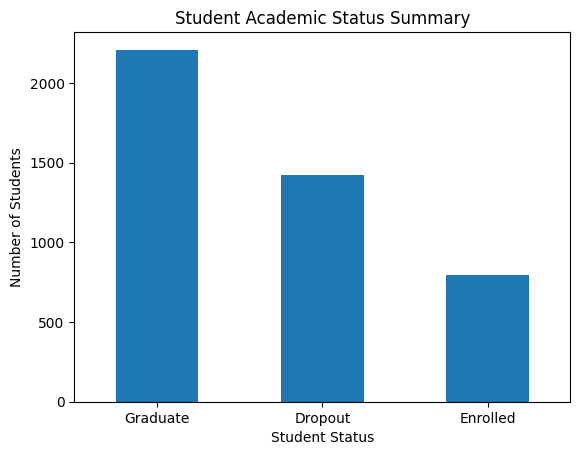

In [44]:
gold_df.plot(
    x="Student_Status",
    y="Student_Count",
    kind="bar",
    legend=False
)

plt.title("Student Academic Status Summary")
plt.xlabel("Student Status")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

## 🤖 Machine Learning

In this stage, a Random Forest classifier is trained to predict the academic status of students using the processed dataset.

In [45]:
from sklearn.preprocessing import LabelEncoder

ml_df = silver_df.copy()

# Encode Target
encoder = LabelEncoder()
ml_df["Target"] = encoder.fit_transform(ml_df["Target"])

X = ml_df.drop("Target", axis=1)
y = ml_df["Target"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (4424, 36)
Target: (4424,)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (3539, 36)
Testing set: (885, 36)


In [47]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## 📊 Model Evaluation

The trained model is evaluated using multiple performance metrics.

In [48]:
predictions = model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy,4))

Accuracy: 0.7605


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.77      0.81       316
           1       0.49      0.30      0.37       151
           2       0.76      0.92      0.83       418

    accuracy                           0.76       885
   macro avg       0.70      0.66      0.67       885
weighted avg       0.75      0.76      0.74       885



In [51]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, predictions)

cm_df = pd.DataFrame(cm)

cm_df

,0,1,2
0,243,23,50
1,35,45,71
2,9,24,385


## ✅ Conclusion

This project successfully demonstrated an end-to-end data engineering pipeline using a real student dropout dataset.

The pipeline included:

- Data Ingestion
- Data Validation
- Bronze Layer
- Silver Layer
- Gold Layer
- Machine Learning Model

The trained Random Forest model was able to classify student academic status using the processed dataset.